Libraries loaded.
  Model   : gpt-4o-mini
  DB path : ./dev/dev_20240627/dev_databases/dev_databases/financial/financial.sqlite
  API Key : OK
Total BIRD questions  : 1534
Financial DB questions: 106

[Difficulty distribution]
difficulty
simple         62
moderate       37
challenging     7
Name: count, dtype: int64

[Sample question]
    question_id difficulty                                                                                     question
89           89   moderate  How many accounts who choose issuance after transaction are staying in East Bohemia region?
90           90     simple                          How many accounts who have region in Prague are eligible for loans?
91           91     simple            The average unemployment ratio of 1995 and 1996, which one has higher percentage?
DDL schema    : 976 chars
SL schema     : 3838 chars

[DDL preview]
CREATE TABLE account (account_id INTEGER, district_id INTEGER, frequency TEXT, date DATE);
CREATE TABLE card (card_

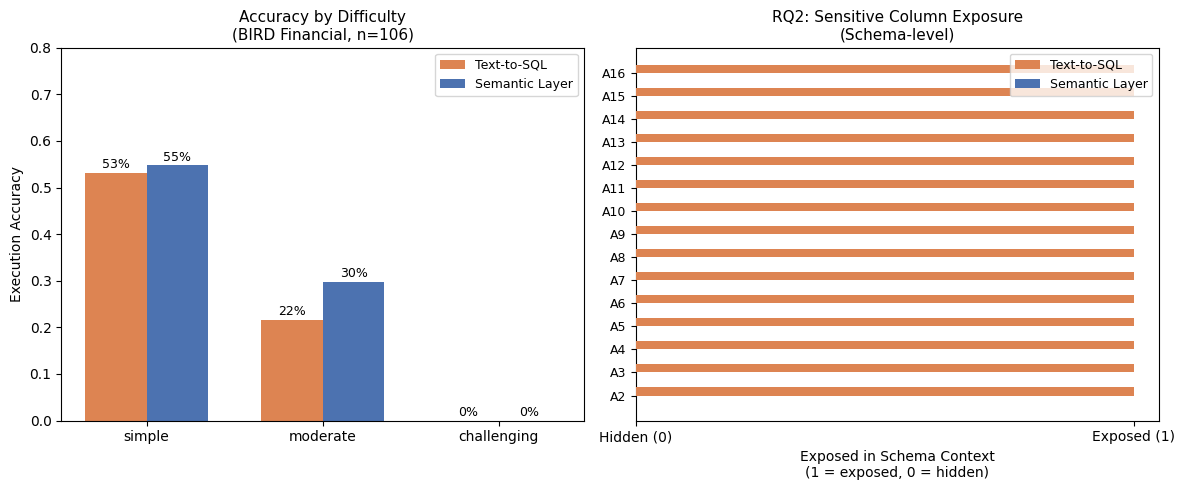

Saved: results_bird_experiment.png


In [1]:
# ============================================================
# bird_financial_experiment.ipynb
# Semantic Layer vs Text-to-SQL
# BIRD Financial Domain Experiment (External Validity)
#
# Dataset : BIRD Dev Set (Li et al., 2023) — financial DB
# Model   : gpt-4o-mini
# Method  : 2 conditions × 106 questions = 212 records
# Author  : [Your Name]
# Date    : 2026-05-14
# ============================================================


# %% [markdown]
# ## 0. Libraries and Configuration

# %%
import os
import json
import sqlite3
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from utils import (
    DB_PATH, YAML_PATH, MODEL,
    get_ddl_schema, get_semantic_schema,
    query_text_to_sql, query_semantic_layer,
    evaluate,
    get_schema_context_sl, measure_exposure,
    SENSITIVE_COLUMNS, SENSITIVE_CODES,
)

load_dotenv()

DEV_DIR  = "./dev/dev_20240627"
DEV_JSON = os.path.join(DEV_DIR, "dev.json")

print("Libraries loaded.")
print(f"  Model   : {MODEL}")
print(f"  DB path : {DB_PATH}")
print(f"  API Key : {'OK' if os.environ.get('OPENAI_API_KEY') else 'MISSING'}")


# %% [markdown]
# ## 1. Load BIRD Dev Set — Financial Domain

# %%
with open(DEV_JSON, "r", encoding="utf-8") as f:
    dev_data = json.load(f)

df_dev     = pd.DataFrame(dev_data)
df_finance = df_dev[df_dev['db_id'] == 'financial'].copy()

print(f"Total BIRD questions  : {len(df_dev)}")
print(f"Financial DB questions: {len(df_finance)}")
print(f"\n[Difficulty distribution]")
print(df_finance['difficulty'].value_counts())
print(f"\n[Sample question]")
print(df_finance[['question_id','difficulty','question']].head(3).to_string())


# %% [markdown]
# ## 2. Schema Verification

# %%
ddl = get_ddl_schema()
sl  = get_semantic_schema()

print(f"DDL schema    : {len(ddl)} chars")
print(f"SL schema     : {len(sl)} chars")
print(f"\n[DDL preview]")
print(ddl[:400])
print(f"\n[SL preview]")
print(sl[:400])


# %% [markdown]
# ## 3. Batch Experiment (106 questions × 2 methods)

# %%
RESULTS_PATH = "./results_phase2_bird_v2.csv"
results      = []
total        = len(df_finance)

print(f"Batch experiment: {total} questions × 2 methods = {total*2} API calls")
print(f"Model  : {MODEL}")
print(f"Prompt : v5 (few-shot + strict column rules)")
print("=" * 62)

for i, (_, row) in enumerate(df_finance.iterrows()):
    q_id       = row['question_id']
    question   = row['question']
    evidence   = row['evidence']
    gold_sql   = row['SQL']
    difficulty = row['difficulty']

    print(f"[{i+1:3d}/{total}] Q{q_id} ({difficulty}) ...", end=" ")

    for method_fn, method_name in [
        (query_text_to_sql,    "text_to_sql"),
        (query_semantic_layer, "semantic_layer"),
    ]:
        try:
            res = method_fn(question, evidence)
            ev  = evaluate(res['sql'], gold_sql)
            results.append({
                "question_id"  : q_id,
                "difficulty"   : difficulty,
                "method"       : method_name,
                "is_correct"   : ev['is_correct'],
                "error"        : ev.get('error'),
                "latency_ms"   : res['latency_ms'],
                "prompt_chars" : res['prompt_chars'],
                "generated_sql": res['sql'],
                "gold_sql"     : gold_sql,
                "question"     : question,
            })
        except Exception as e:
            results.append({
                "question_id"  : q_id,
                "difficulty"   : difficulty,
                "method"       : method_name,
                "is_correct"   : False,
                "error"        : str(e),
                "latency_ms"   : None,
                "prompt_chars" : None,
                "generated_sql": None,
                "gold_sql"     : gold_sql,
                "question"     : question,
            })

    # Save after every question
    pd.DataFrame(results).to_csv(RESULTS_PATH, index=False, encoding="utf-8-sig")

    # Running accuracy
    df_tmp  = pd.DataFrame(results)
    acc     = df_tmp.groupby('method')['is_correct'].mean()
    sql_acc = acc.get('text_to_sql',    float('nan'))
    sl_acc  = acc.get('semantic_layer', float('nan'))
    print(f"SQL={sql_acc:.1%}  SL={sl_acc:.1%}")

    time.sleep(0.5)

print("=" * 62)
print(f"Experiment complete. Saved: {RESULTS_PATH}")
print(f"\n[Final Accuracy]")
print(pd.DataFrame(results).groupby('method')['is_correct'].mean().round(3))


# %% [markdown]
# ## 4. Results Analysis

# %%
df_res = pd.read_csv(RESULTS_PATH)

overall = df_res.groupby('method')['is_correct'].mean().round(3)
by_diff = df_res.groupby(['difficulty','method'])['is_correct'].mean().round(3).unstack()

print("=" * 55)
print("[1] Overall Accuracy (n=106)")
print("=" * 55)
print(overall)
diff = overall['semantic_layer'] - overall['text_to_sql']
print(f"\nDifference: {diff:+.3f} ({'SL' if diff>0 else 'SQL'} advantage)")

print("\n[2] Accuracy by Difficulty")
print(by_diff)

print("\n[3] Error Analysis")
for method in ['text_to_sql', 'semantic_layer']:
    sub    = df_res[df_res['method'] == method]
    label  = 'Semantic Layer' if method == 'semantic_layer' else 'Text-to-SQL'
    correct= int(sub['is_correct'].sum())
    errors = int(sub['error'].notna().sum())
    n      = len(sub)
    print(f"  [{label}] correct={correct}/{n} ({correct/n:.1%})  "
          f"exec_errors={errors} ({errors/n:.1%})")

print("\n[4] Latency (ms)")
print(df_res.groupby('method')['latency_ms'].agg(['mean','median','std']).round(1))

print("\n[5] Question-level Breakdown")
pivot = df_res.pivot(index='question_id', columns='method', values='is_correct')
print(f"  Both correct : {int(( pivot['text_to_sql'] &  pivot['semantic_layer']).sum())}")
print(f"  Only SQL     : {int(( pivot['text_to_sql'] & ~pivot['semantic_layer']).sum())}")
print(f"  Only SL      : {int((~pivot['text_to_sql'] &  pivot['semantic_layer']).sum())}")
print(f"  Both wrong   : {int((~pivot['text_to_sql'] & ~pivot['semantic_layer']).sum())}")


# %% [markdown]
# ## 5. RQ2 — Sensitive Information Exposure

# %%
import re

schema_sql = get_ddl_schema()
schema_sl  = get_schema_context_sl()

exp_sql = measure_exposure(schema_sql)
exp_sl  = measure_exposure(schema_sl)

print("=" * 55)
print("RQ2: Schema-level Sensitive Information Exposure")
print("=" * 55)

rows = [
    ("Sensitive columns exposed (distinct)", "col_exposed"),
    ("Sensitive columns (total mentions)",   "col_total"),
    ("Internal codes exposed (distinct)",    "code_exposed"),
    ("Internal codes (total mentions)",      "code_total"),
]
for label, key in rows:
    sql_v = exp_sql[key]
    sl_v  = exp_sl[key]
    red   = (sql_v - sl_v) / sql_v * 100 if sql_v > 0 else 0.0
    print(f"\n  {label}")
    print(f"    Text-to-SQL    : {sql_v}")
    print(f"    Semantic Layer : {sl_v}")
    print(f"    Reduction      : {red:+.1f}%")

print(f"\n[Column-level detail]")
print(f"  {'Column':<8} {'SQL':>6} {'SL':>6}")
print("  " + "-" * 22)
for col in SENSITIVE_COLUMNS:
    sql_c = exp_sql['col_detail'][col]
    sl_c  = exp_sl['col_detail'][col]
    flag  = " ✓" if sl_c == 0 and sql_c > 0 else ""
    print(f"  {col:<8} {sql_c:>6} {sl_c:>6}{flag}")

# Save exposure results
import pandas as pd
exp_rows = []
for col in SENSITIVE_COLUMNS:
    exp_rows.append({
        'token'     : col,
        'type'      : 'column',
        'sql_count' : exp_sql['col_detail'][col],
        'sl_count'  : exp_sl['col_detail'][col],
        'hidden_by_sl': exp_sl['col_detail'][col] == 0 and exp_sql['col_detail'][col] > 0,
    })
for code in SENSITIVE_CODES:
    exp_rows.append({
        'token'     : code,
        'type'      : 'code',
        'sql_count' : exp_sql['code_detail'][code],
        'sl_count'  : exp_sl['code_detail'][code],
        'hidden_by_sl': exp_sl['code_detail'][code] == 0 and exp_sql['code_detail'][code] > 0,
    })

pd.DataFrame(exp_rows).to_csv(
    './results_phase2_exposure_v2.csv', index=False, encoding='utf-8-sig'
)
print("\nSaved: results_phase2_exposure_v2.csv")


# %% [markdown]
# ## 6. Visualization

# %%
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
w = 0.35

# Figure 1: Accuracy by difficulty
ax1   = axes[0]
diffs = ['simple', 'moderate', 'challenging']
x     = np.arange(len(diffs))
for j, (method, color, label) in enumerate([
    ('text_to_sql',    '#DD8452', 'Text-to-SQL'),
    ('semantic_layer', '#4C72B0', 'Semantic Layer'),
]):
    vals = [by_diff.loc[d, method] if d in by_diff.index else 0 for d in diffs]
    bars = ax1.bar(x + (j-0.5)*w, vals, w, label=label, color=color)
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x()+bar.get_width()/2, val+0.01,
                 f'{val:.0%}', ha='center', fontsize=9)
ax1.set_title('Accuracy by Difficulty\n(BIRD Financial, n=106)', fontsize=11)
ax1.set_xticks(x); ax1.set_xticklabels(diffs)
ax1.set_ylabel('Execution Accuracy')
ax1.set_ylim(0, 0.8); ax1.legend(fontsize=9)

# Figure 2: Sensitive column exposure
ax2   = axes[1]
items = SENSITIVE_COLUMNS
y     = np.arange(len(items))
h     = 0.35
sql_e = [exp_sql['col_detail'][c] for c in items]
sl_e  = [exp_sl['col_detail'][c]  for c in items]
ax2.barh(y + h/2, sql_e, h, label='Text-to-SQL',    color='#DD8452', zorder=3)
ax2.barh(y - h/2, sl_e,  h, label='Semantic Layer', color='#4C72B0', zorder=3)
ax2.set_yticks(y); ax2.set_yticklabels(items, fontsize=9)
ax2.set_xlabel('Exposed in Schema Context\n(1 = exposed, 0 = hidden)')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Hidden (0)', 'Exposed (1)'])
ax2.set_title('RQ2: Sensitive Column Exposure\n(Schema-level)', fontsize=11)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('results_bird_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results_bird_experiment.png")